In [7]:
%matplotlib inline

In [8]:
import fastcat as fc
import numpy as np
import matplotlib.pyplot as plt
import spekpy as sp

What to do?

1) find dose using the mass absorption coeff for a full beam
2) Find signal
    a) Find attenuation coefficients
        i) Discrete sum over energies
    b) Find their standard deviation
        i) Using statistics
    c) Calculate the signal to noise ratio in high and low bins in a loop over:
        i) filtration
        ii) Bins
        iii) Use a gradient descent method?

In [9]:
%matplotlib widget

In [4]:
# Get attenuation coefficient for Bismuth

mu_bi=fc.get_mu(z=79)
# Get attenuation coefficient for Gadolinium
mu_gd=fc.get_mu(z=64)

energies = np.linspace(10, 500, 5000)

mu_bismuth = [mu_bi(energy) for energy in energies]
mu_gadolinium = [mu_gd(energy) for energy in energies]

# Add the k-edge energies to the plot
k_bi = 80.7
k_gd = 50.2

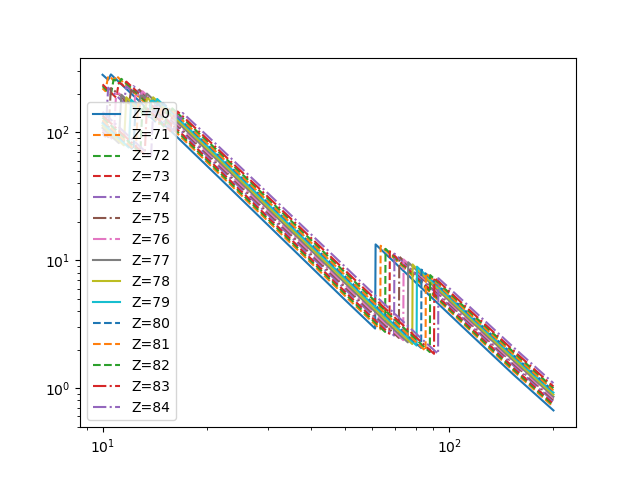

In [38]:
# plot the linear attenuation coefficients of some of the heavier elements

atomic_numbers = np.arange(70, 85, 1)
energies = np.linspace(10, 200, 1000)
plt.figure()
linestyles = ['-', '--', '-.', ':']
for z in atomic_numbers:
    mu = fc.get_mu(z)
    density = xrd.atomic_density(int(z))
    plt.loglog(energies, [mu(energy)/density for energy in energies], label=f'Z={z}', linestyle=linestyles[int(((z-50)/3)%3)])

plt.legend()

In [5]:
def get_parameters():
    """Return the parameters from Table 3"""
    return {
        'a1': 0.5,
        'a2': 0.015,  # keV^-1
        'a3': 0.042,  # keV^-1
        'a4': 0.213e-3,  # keV^-2
        'a5': 1.61,   # keV
        'a6': 0.025
    }

def c2(E, Ee, a1, a2):
    """
    Piecewise function for c2(E)
    E: energy in keV
    Ee: escape energy (~25 keV for CdTe)
    """
    return np.where(E > Ee, a1 * np.exp(-a2 * E), 0)

def c3(E, a3, a4):
    """Linear function for c3(E)"""
    return a3 - a4 * E

def sigma(E, a5, a6):
    """Linear function for σ(E)"""
    return a5 + a6 * E

def background(U, E, c3_val, sigma_val):
    """
    Calculate background B(U,E)
    - Constant value of c3 for U < (E - 3σ₁)
    - Linearly ramped down to zero within width of 6σ₁
    """
    threshold = E - 3 * sigma_val
    ramp_width = 6 * sigma_val
    
    # Create the piecewise function
    background = np.where(
        U < threshold,
        c3_val,  # constant value below threshold
        np.where(
            U < threshold + ramp_width,
            # Linear ramp from c3 to 0 over 6σ₁ width
            c3_val * (1 - (U - threshold) / ramp_width),
            0  # zero above threshold + ramp_width
        )
    )
    return background

def response_function(U, E, c1):
    """
    Calculate the response function R(U,E) with the specific parameters from the paper
    
    Parameters:
    U : float or array-like
        Measured energy (keV)
    E : float or array-like
        Incident energy (keV)
    c1 : float or callable
        First coefficient (preserves number of photons of incoming flux)
    
    Returns:
    float or array-like: The calculated response value(s)
    """
    # Get parameters
    params = get_parameters()
    Ee = 25.0  # escape energy for CdTe in keV
    
    # Calculate coefficients
    c1_val = c1(E) if callable(c1) else c1
    c2_val = c2(E, Ee, params['a1'], params['a2'])
    c3_val = c3(E, params['a3'], params['a4'])
    
    # Calculate sigma (same for both terms)
    sigma_val = sigma(E, params['a5'], params['a6'])
    
    # Calculate the Gaussian terms
    gaussian1 = (1 / (np.sqrt(2*np.pi) * sigma_val)) * \
                np.exp(-0.5 * ((U - E)**2) / (sigma_val**2))
    
    # For escape peak, shift energy by Ee
    gaussian2 = (1 / (np.sqrt(2*np.pi) * sigma_val)) * \
                np.exp(-0.5 * ((U - (E - Ee))**2) / (sigma_val**2))
    
    # Calculate background term
    B = background(U, E, c3_val, sigma_val)
    
    # Combine all terms
    result = c1_val * gaussian1 + c2_val * gaussian2 + B
    
    return result

def detector_response(energy_spectrum, energies, c1):
    """
    Calculate the detector response to an energy spectrum
    
    Parameters:
    energy_spectrum : array-like
        The energy spectrum (number of photons at each energy)
    energies : array-like
        The energies corresponding to the energy spectrum
    c1 : float or callable
        First coefficient (preserves number of photons of incoming flux)
    
    Returns:
    array-like: The detector response
    """
    U = np.linspace(min(energies), max(energies), len(energies))
    response = np.zeros_like(U)
    
    for E, spectrum_value in zip(energies, energy_spectrum):
        response += spectrum_value * response_function(U, E, c1)
    
    return U, response

k bi index low 159
Fluence between W and Bi k-edges (120 kVp, 1 mm Cu, 0.89 mm Bi): 0.37
Fluence between W and Bi k-edges (140 kVp, 1 mm Cu, 0.89 mm Bi): 0.90
Fluence above Bi k-edge (120 kVp, 1 mm Cu, 0.89 mm Bi): 0.56
Fluence above Bi k-edge (140 kVp, 1 mm Cu, 0.89 mm Bi): 0.90
Mean energy between W and Bi k-edges (120 kVp, 1 mm Cu, 0.89 mm Bi): 74.39 keV
Mean energy between W and Bi k-edges (140 kVp, 1 mm Cu, 0.89 mm Bi): 76.33 keV
Mean energy above Bi k-edge (120 kVp, 1 mm Cu, 0.89 mm Bi): 84.67 keV
Mean energy above Bi k-edge (140 kVp, 1 mm Cu, 0.89 mm Bi): 128.71 keV
Mass attenuation coefficient at mean energy between W and Bi k-edges (140 kVp, 1 mm Cu, 0.89 mm Bi): 47.54 cm^2/g
Mass attenuation coefficient at mean energy between W and Bi k-edges (120 kVp, 1 mm Cu, 0.89 mm Bi): 50.74 cm^2/g
Mass attenuation coefficient at mean energy above Bi k-edge (140 kVp, 1 mm Cu, 0.89 mm Bi): 52.81 cm^2/g
Mass attenuation coefficient at mean energy above Bi k-edge (120 kVp, 1 mm Cu, 0.89 mm 

/tmp/ipykernel_6341/1455004360.py:75: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,8))


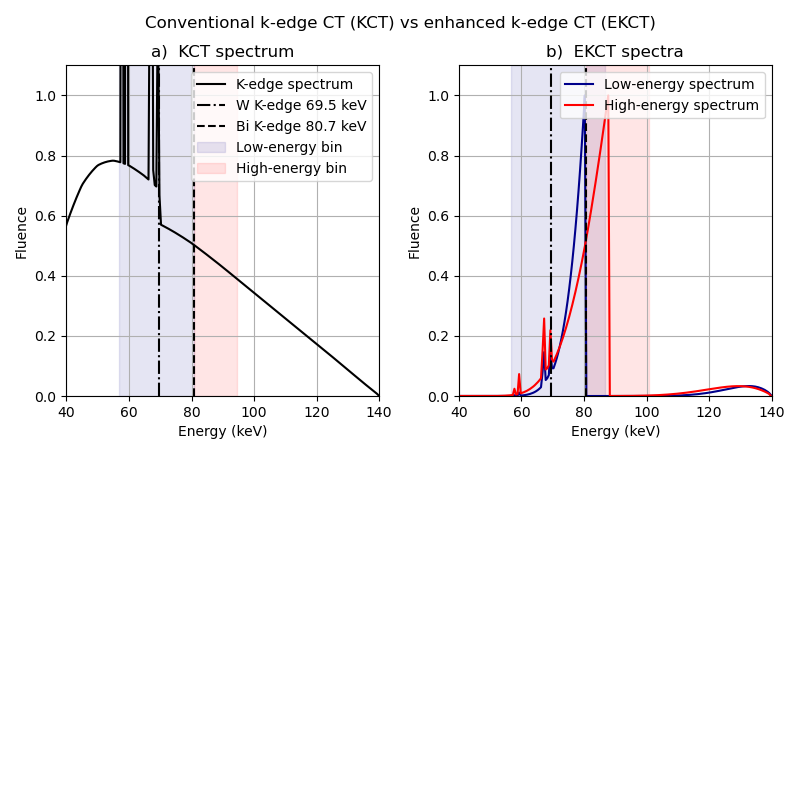

In [40]:
# Generate spectra
s_low = sp.Spek(140, 14)
s_low.filter('Au', 1.5)
s_low.filter('Water', 80)
xx_low, yy_low = s_low.get_spectrum()

s_high = sp.Spek(140, 14)
s_high.filter('Pb', 1.5)
s_high.filter('Water', 80)
xx_high, yy_high = s_high.get_spectrum()
yy_high[-1] = 0  # Insert another entry of 121 keV 0 fluence to the spectrum

# xx_high = np.insert(xx_high, -1, 111)


k_20 = 20
k_W = 80.7 - 24
k_top = 80.7 + 14

# Find the closes xx and xx2 values to the k-edge energies
k_bi_index_high = np.argmin(np.abs(xx_high - k_bi))
k_bi_index_low = np.argmin(np.abs(xx_low - k_bi))
k_W_index_high = np.argmin(np.abs(xx_high - k_W))
k_W_index_low = np.argmin(np.abs(xx_low - k_W))
k_top_index_high = np.argmin(np.abs(xx_high - k_top))
k_top_index_low = np.argmin(np.abs(xx_low - k_top))

k_20_index_low = np.argmin(np.abs(xx_low - 20))
k_20_index_high = np.argmin(np.abs(xx_high - 20))

# Calculate the percent of the fluence between the k-edges 

fluence_W_to_bi_high = np.sum(yy_high[k_W_index_high:k_bi_index_high]) / np.sum(yy_high)
fluence_W_to_bi_low = np.sum(yy_low[k_W_index_low:k_bi_index_low]) / np.sum(yy_low)
fluence_bi_high = np.sum(yy_high[k_bi_index_high:k_top_index_high]) / np.sum(yy_high)
fluence_bi_low = np.sum(yy_low[:k_bi_index_low]) / np.sum(yy_low)

# Find the mean energy in each num_regions
mean_energy_high = np.mean(xx_high*(yy_high/np.sum(yy_high)))
mean_energy_low = np.mean(xx_low*(yy_low/np.sum(yy_low)))

# Calculate the mean energy in each num_regions as a weighted average of the energy time the fluence in each bin

mean_energy_W_to_bi_high = np.sum(xx_high[k_W_index_high:k_bi_index_high]*(yy_high[k_W_index_high:k_bi_index_high]/np.sum(yy_high[k_W_index_high:k_bi_index_high])))
mean_energy_W_to_bi_low = np.sum(xx_low[k_W_index_low:k_bi_index_low]*(yy_low[k_W_index_low:k_bi_index_low]/np.sum(yy_low[k_W_index_low:k_bi_index_low])))
mean_energy_bi_high = np.sum(xx_high[k_bi_index_high:k_top_index_high]*(yy_high[k_bi_index_high:k_top_index_high]/np.sum(yy_high[k_bi_index_high:k_top_index_high])))
mean_energy_bi_low = np.sum(xx_low[k_bi_index_low:]*(yy_low[k_bi_index_low:]/np.sum(yy_low[k_bi_index_low:])))

print('k bi index low', k_bi_index_low)

print(f'Fluence between W and Bi k-edges (120 kVp, 1 mm Cu, 0.89 mm Bi): {fluence_W_to_bi_high:.2f}')
print(f'Fluence between W and Bi k-edges (140 kVp, 1 mm Cu, 0.89 mm Bi): {fluence_W_to_bi_low:.2f}')
print(f'Fluence above Bi k-edge (120 kVp, 1 mm Cu, 0.89 mm Bi): {fluence_bi_high:.2f}')
print(f'Fluence above Bi k-edge (140 kVp, 1 mm Cu, 0.89 mm Bi): {fluence_bi_low:.2f}')
print(f'Mean energy between W and Bi k-edges (120 kVp, 1 mm Cu, 0.89 mm Bi): {mean_energy_W_to_bi_high:.2f} keV')
print(f'Mean energy between W and Bi k-edges (140 kVp, 1 mm Cu, 0.89 mm Bi): {mean_energy_W_to_bi_low:.2f} keV')
print(f'Mean energy above Bi k-edge (120 kVp, 1 mm Cu, 0.89 mm Bi): {mean_energy_bi_high:.2f} keV')
print(f'Mean energy above Bi k-edge (140 kVp, 1 mm Cu, 0.89 mm Bi): {mean_energy_bi_low:.2f} keV')

mu_at_mean_energy_W_to_bi_low = mu_bi(mean_energy_W_to_bi_low)
mu_at_mean_energy_W_to_bi_high = mu_bi(mean_energy_W_to_bi_high)
mu_at_mean_energy_bi_low = mu_bi(mean_energy_bi_low)
mu_at_mean_energy_bi_high = mu_bi(mean_energy_bi_high)

print(f'Mass attenuation coefficient at mean energy between W and Bi k-edges (140 kVp, 1 mm Cu, 0.89 mm Bi): {mu_at_mean_energy_W_to_bi_low:.2f} cm^2/g')
print(f'Mass attenuation coefficient at mean energy between W and Bi k-edges (120 kVp, 1 mm Cu, 0.89 mm Bi): {mu_at_mean_energy_W_to_bi_high:.2f} cm^2/g')
print(f'Mass attenuation coefficient at mean energy above Bi k-edge (140 kVp, 1 mm Cu, 0.89 mm Bi): {mu_at_mean_energy_bi_low:.2f} cm^2/g')
print(f'Mass attenuation coefficient at mean energy above Bi k-edge (120 kVp, 1 mm Cu, 0.89 mm Bi): {mu_at_mean_energy_bi_high:.2f} cm^2/g')


yy_low/=np.max(yy_low)
yy_high/=np.max(yy_high) #0.915
# Plot the spectra
bin_info = '110 kVp, 1 mm Cu, 0.89 mm Bi'
plt.figure(figsize=(8,8))
plt.subplot(2,2,2)
plt.plot(xx_low, yy_low, label='Low-energy spectrum', c='darkblue')
plt.title('b)  EKCT spectra')
plt.plot(xx_high, yy_high, label='High-energy spectrum',c='red')
plt.axvline(69.5, color='k', linestyle='-.')
plt.axvline(k_bi, color='k', linestyle='--')
plt.ylim(0,1.1)
plt.xlim(40,140)

plt.axvspan(k_W, k_bi+6, color='darkblue', alpha=0.1)
plt.axvspan(k_bi, k_top+6, color='red', alpha=0.1)

# plt.text((k_bi+k_W)/2, 0.5*max(yy_low), f'{mu_at_mean_energy_W_to_bi_low:.2f}\ncm$^{-1}$',color='blue',ha='center')
# plt.text((k_bi+max(xx_high))/2, 0.5*max(yy_high), f'{mu_at_mean_energy_bi_high:.2f}\ncm$^{-1}$',color='blue',ha='center')

plt.xlabel('Energy (keV)')
plt.ylabel('Fluence')
plt.grid()
plt.legend()

s_norm = sp.Spek(140,14)
s_norm.filter('Al',4)
# s_low.filter('Bi',0.89)
s_norm.filter('Water',80)
# s_low.filter('Cu',1)

xx_norm, yy_norm = s_norm.get_spectrum()

yy_norm/=0.134*np.max(yy_norm)

plt.suptitle('Conventional k-edge CT (KCT) vs enhanced k-edge CT (EKCT)')
plt.subplot(2,2,1)
plt.plot(xx_norm, yy_norm, label='K-edge spectrum', c='k')
plt.title('a)  KCT spectrum')
plt.axvline(69.5, color='k', linestyle='-.', label=f'W K-edge 69.5 keV')
plt.axvline(k_bi, color='k', linestyle='--', label=f'Bi K-edge {k_bi} keV')
plt.axvspan(k_W, k_bi, color='darkblue', alpha=0.1, label='Low-energy bin')
plt.axvspan(k_bi, k_top, color='red', alpha=0.1, label='High-energy bin')
plt.ylim(0,1.1)
plt.xlim(40,140)
plt.xlabel('Energy (keV)')
plt.ylabel('Fluence')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

c1 = 1

U_high, response_high = detector_response(yy_high, xx_norm, c1)
U_low, response_low = detector_response(yy_low, xx_norm, c1)
U_norm, response_norm = detector_response(yy_norm, xx_norm, c1)

m_response_high = np.max(response_high)
m_response_low = np.max(response_low)
m_response_norm = np.max(response_norm)

response_high/=np.max(response_high)
response_low/=np.max(response_low)
response_norm/=np.max(response_norm)

import matplotlib.pyplot as plt

k_bi_index_low2 = np.argmin(np.abs(xx_low - (k_bi + 6)))
k_top_index_high2 = np.argmin(np.abs(xx_norm - (112)))

# interpolate xx_high and yy_high to xx_norm
yy_high = np.interp(xx_norm, xx_high, yy_high)

U_high2, response_high_true = detector_response(yy_high[k_bi_index_high:k_top_index_high2], xx_norm[k_bi_index_high:k_top_index_high2], c1)
U_low2, response_low_true = detector_response(yy_low[k_W_index_low:k_bi_index_low2], xx_low[k_W_index_low:k_bi_index_low2], c1)
U_norm_low, response_norm_true_low = detector_response(yy_norm[k_W_index_low:k_bi_index_low], xx_norm[k_W_index_low:k_bi_index_low], c1)
U_norm_high, response_norm_true_high = detector_response(yy_norm[k_bi_index_low:k_top_index_low], xx_norm[k_bi_index_high:k_top_index_high], c1)

response_high_true/=m_response_high
response_low_true/=m_response_low
response_norm_true_low/=m_response_norm
response_norm_true_high/=m_response_norm

# plt.figure(figsize=(8,8))
plt.subplot(2,2,4)
plt.plot(U_low, response_low, label='Low-energy detector response', c='darkblue',alpha=0.4)
plt.plot(U_high, response_high, label='High-energy detector response', c='red',alpha=0.4)
plt.title('d)  EKCT detector response')


response_low_false= response_low[k_W_index_low:k_bi_index_low2] - response_low_true
response_high_false = response_high[k_bi_index_high:k_top_index_high2] - response_high_true
response_norm_false_low = response_norm[k_W_index_low:k_bi_index_low] - response_norm_true_low
response_norm_false_high = response_norm[k_bi_index_low:k_top_index_low] - response_norm_true_high

plt.plot(U_low2, response_low_true, label='Low-energy detector response', c='darkblue', linestyle='--')
plt.plot(U_high2, response_high_true, label='High-energy detector response', c='red', linestyle='--')
plt.plot(U_low2, response_low_false, label='Low-energy detector response', c='darkblue', linestyle=':')
plt.plot(U_high2, response_high_false, label='High-energy detector response', c='red', linestyle=':')
# plt.axvline(69.5, color='k', linestyle='-.')
# plt.axvline(k_bi, color='k', linestyle='--')
plt.axvspan(k_W, k_bi+6, color='darkblue', alpha=0.1)
plt.axvspan(k_bi, k_top+6, color='red', alpha=0.1)
plt.xlim(40,140)
plt.ylim(0,1.1)
plt.xlabel('Measured energy (keV)')
plt.ylabel('Counts')
plt.grid()

plt.subplot(2,2,3)
plt.plot(U_norm, response_norm, alpha=0.4,label='Total', c='k')
plt.plot(U_norm_low, response_norm_true_low, label='True', c='k', linestyle='--')
plt.plot(U_norm_high, response_norm_true_high, c='k', linestyle='--')
plt.plot(U_norm_low, response_norm_false_low, label='False', c='k', linestyle=':')
plt.plot(U_norm_high, response_norm_false_high, c='k', linestyle=':')
plt.title('c)  KCT detector response')
plt.axvspan(k_W, k_bi, color='darkblue', alpha=0.1)
plt.axvspan(k_bi, k_top-1, color='red', alpha=0.1)
plt.xlim(40,140)
plt.ylim(0,1.1)
plt.legend()
plt.xlabel('Measured energy (keV)')
plt.ylabel('Counts')
plt.grid()

plt.tight_layout()

# plt.savefig('EKCT_response.png')

In [18]:
print('EKCT detector response')
print(f'Percent of true counts in the low-energy bin (110 kVp, 1 mm Cu, 0.89 mm Bi): {np.sum(response_low_true)/np.sum(response_low):.2f}')
print(f'Percent of true counts in the high-energy bin (110 kVp, 6 mm Cu): {np.sum(response_high_true)/np.sum(response_high):.2f}')

print('Conventional detector response')
print(f'Percent of true counts in the low-energy bin (140 kVp, 1 mm Cu, 0.89 mm Bi): {np.sum(response_norm_true_low)/np.sum(response_norm):.2f}')
print(f'Percent of true counts in the high-energy bin (140 kVp, 6 mm Cu): {np.sum(response_norm_true_high)/np.sum(response_norm):.2f}')

print('EKCT fluence ratios')
print(f'Ratio of fluence in the low bin to the total fluence (110 kVp, 1 mm Cu, 0.89 mm Bi): {np.sum(yy_low[k_W_index_low:k_bi_index_low]) / np.sum(yy_low):.2f}')
print(f'Ratio of fluence in the high bin to the total fluence (110 kVp, 6 mm Cu): {np.sum(yy_high[k_bi_index_high:k_top_index_high]) / np.sum(yy_high):.2f}')

print('Conventional fluence ratios')
print(f'Ratio of fluence in the low bin to the total fluence (140 kVp, 1 mm Cu, 0.89 mm Bi): {np.sum(yy_norm[k_W_index_low:k_bi_index_low]) / np.sum(yy_norm):.2f}')
print(f'Ratio of fluence in the high bin to the total fluence (140 kVp, 6 mm Cu): {np.sum(yy_norm[k_bi_index_low:k_top_index_low]) / np.sum(yy_norm):.2f}')

print('EKCT ratios')
print(f'Ratio of true counts in the low-energy bin to counts in the low-energy bin (110 kVp, 1 mm Cu, 0.89 mm Bi): {np.sum(response_low_true)/(np.sum(response_low_true) + np.sum(response_low_false)):.2f}')
print(f'Ratio of true counts in the high-energy bin to counts in the high-energy bin (110 kVp, 6 mm Cu): {np.sum(response_high_true)/(np.sum(response_high_true) + np.sum(response_high_false)):.2f}')

print('Conventional ratios')
print(f'Ratio of true counts in the low-energy bin to counts in the low-energy bin (140 kVp, 1 mm Cu, 0.89 mm Bi): {np.sum(response_norm_true_low)/(np.sum(response_norm_true_low) + np.sum(response_norm_false_low)):.2f}')
print(f'Ratio of true counts in the high-energy bin to counts in the high-energy bin (140 kVp, 6 mm Cu): {np.sum(response_norm_true_high)/(np.sum(response_norm_true_high) + np.sum(response_norm_false_high)):.2f}')

print('EKCT false counts')
print(f'False counts in the low-energy bin (110 kVp, 1 mm Cu, 0.89 mm Bi): {np.sum(response_low_false)/(np.sum(response_low_true) + np.sum(response_low_false)):.2f}')
print(f'False counts in the high-energy bin (110 kVp, 6 mm Cu): {np.sum(response_high_false)/(np.sum(response_high_true) + np.sum(response_high_false)):.2f}')

print('Conventional false counts')
print(f'False counts in the low-energy bin (140 kVp, 1 mm Cu, 0.89 mm Bi): {np.sum(response_norm_false_low)/(np.sum(response_norm_true_low) + np.sum(response_norm_false_low)):.2f}')
print(f'False counts in the high-energy bin (140 kVp, 6 mm Cu): {np.sum(response_norm_false_high)/(np.sum(response_norm_true_high) + np.sum(response_norm_false_high)):.2f}')



EKCT detector response
Percent of true counts in the low-energy bin (110 kVp, 1 mm Cu, 0.89 mm Bi): 0.42
Percent of true counts in the high-energy bin (110 kVp, 6 mm Cu): 0.21
Conventional detector response
Percent of true counts in the low-energy bin (140 kVp, 1 mm Cu, 0.89 mm Bi): 0.16
Percent of true counts in the high-energy bin (140 kVp, 6 mm Cu): 0.04
EKCT fluence ratios
Ratio of fluence in the low bin to the total fluence (110 kVp, 1 mm Cu, 0.89 mm Bi): 0.88
Ratio of fluence in the high bin to the total fluence (110 kVp, 6 mm Cu): 0.67
Conventional fluence ratios
Ratio of fluence in the low bin to the total fluence (140 kVp, 1 mm Cu, 0.89 mm Bi): 0.42
Ratio of fluence in the high bin to the total fluence (140 kVp, 6 mm Cu): 0.12
EKCT ratios
Ratio of true counts in the low-energy bin to counts in the low-energy bin (110 kVp, 1 mm Cu, 0.89 mm Bi): 0.96
Ratio of true counts in the high-energy bin to counts in the high-energy bin (110 kVp, 6 mm Cu): 0.89
Conventional ratios
Ratio of

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def get_parameters():
    """Return the parameters from Table 3"""
    return {
        'a1': 0.5,
        'a2': 0.015,  # keV^-1
        'a3': 0.042,  # keV^-1
        'a4': 0.213e-3,  # keV^-2
        'a5': 1.61,   # keV
        'a6': 0.025
    }

def c2(E, Ee, a1, a2):
    """
    Piecewise function for c2(E)
    E: energy in keV
    Ee: escape energy (~25 keV for CdTe)
    """
    return np.where(E > Ee, a1 * np.exp(-a2 * E), 0)

def c3(E, a3, a4):
    """Linear function for c3(E)"""
    return a3 - a4 * E

def sigma(E, a5, a6):
    """Linear function for σ(E)"""
    return a5 + a6 * E

def background(U, E, c3_val, sigma_val):
    """
    Calculate background B(U,E)
    - Constant value of c3 for U < (E - 3σ₁)
    - Linearly ramped down to zero within width of 6σ₁
    """
    threshold = E - 3 * sigma_val
    ramp_width = 6 * sigma_val
    
    # Create the piecewise function
    background = np.where(
        U < threshold,
        c3_val,  # constant value below threshold
        np.where(
            U < threshold + ramp_width,
            # Linear ramp from c3 to 0 over 6σ₁ width
            c3_val * (1 - (U - threshold) / ramp_width),
            0  # zero above threshold + ramp_width
        )
    )
    return background

def response_function(U, E, c1):
    """
    Calculate the response function R(U,E) with the specific parameters from the paper
    
    Parameters:
    U : float or array-like
        Measured energy (keV)
    E : float or array-like
        Incident energy (keV)
    c1 : float or callable
        First coefficient (preserves number of photons of incoming flux)
    
    Returns:
    float or array-like: The calculated response value(s)
    """
    # Get parameters
    params = get_parameters()
    Ee = 25.0  # escape energy for CdTe in keV
    
    # Calculate coefficients
    c1_val = c1(E) if callable(c1) else c1
    c2_val = c2(E, Ee, params['a1'], params['a2'])
    c3_val = c3(E, params['a3'], params['a4'])
    
    # Calculate sigma (same for both terms)
    sigma_val = sigma(E, params['a5'], params['a6'])
    
    # Calculate the Gaussian terms
    gaussian1 = (1 / (np.sqrt(2*np.pi) * sigma_val)) * \
                np.exp(-0.5 * ((U - E)**2) / (sigma_val**2))
    
    # For escape peak, shift energy by Ee
    gaussian2 = (1 / (np.sqrt(2*np.pi) * sigma_val)) * \
                np.exp(-0.5 * ((U - (E - Ee))**2) / (sigma_val**2))
    
    # Calculate background term
    B = background(U, E, c3_val, sigma_val)
    
    # Combine all terms
    result = c1_val * gaussian1 + c2_val * gaussian2 + B
    
    return result

def detector_response(energy_spectrum, energies, c1):
    """
    Calculate the detector response to an energy spectrum
    
    Parameters:
    energy_spectrum : array-like
        The energy spectrum (number of photons at each energy)
    energies : array-like
        The energies corresponding to the energy spectrum
    c1 : float or callable
        First coefficient (preserves number of photons of incoming flux)
    
    Returns:
    array-like: The detector response
    """
    U = np.linspace(min(energies), max(energies), len(energies))
    response = np.zeros_like(U)
    contributions = np.zeros((len(energies), len(U)))
    
    for i, (E, spectrum_value) in enumerate(zip(energies, energy_spectrum)):
        response_contribution = spectrum_value * response_function(U, E, c1)
        response += response_contribution
        contributions[i] = response_contribution
    
    return U, response, contributions

def average_energy_in_bin(U, contributions, bin_start, bin_end):
    """
    Calculate the average energy of an energy bin in a detector response
    
    Parameters:
    U : array-like
        Measured energy (keV)
    contributions : array-like
        Contributions to the detector response from each energy
    bin_start : float
        Start of the energy bin (keV)
    bin_end : float
        End of the energy bin (keV)
    
    Returns:
    float: The average energy of the energy bin
    """
    bin_mask = (U >= bin_start) & (U < bin_end)
    bin_contributions = contributions[:, bin_mask]

    mu_bismuth = [mu_bi(U_i) for U_i in U]

    bin_contrib = np.sum(bin_contributions, axis=1)
    bin_contrib /= np.sum(bin_contrib)
    bin_attenuation = bin_contrib * mu_bismuth

    total_contributions = np.sum(bin_attenuation)
    
    return total_contributions/10


In [45]:
s_low = sp.Spek(140,14)
s_low.filter('Hg',0.4)
s_low.filter('Au',0.4)
s_low.filter('Tl',0.4)
# s_low.filter('Water',80)
# s_low.filter('Cu',1)

xx_low, yy_low = s_low.get_spectrum()

s_high = sp.Spek(140,14)
# s_high.filter('U',1)
s_high.filter('Pb',2)
s_high.filter('Water',80)
# s_high.filter('Cu',8)


# Insert another entry of 121 keV 0 fluence to the spectrum
yy_high[-1] = 0

k_bi = 80.7
k_W = 80.7 - 10
k_top = 80.7 + 10

# Find the closest xx and xx2 values to the k-edge energies
k_bi_index_high = np.argmin(np.abs(xx_high - k_bi))
k_bi_index_low = np.argmin(np.abs(xx_low - k_bi))
k_W_index_high = np.argmin(np.abs(xx_high - k_W))
k_W_index_low = np.argmin(np.abs(xx_low - k_W))
k_top_index_high = np.argmin(np.abs(xx_high - k_top))
k_top_index_low = np.argmin(np.abs(xx_low - k_top))

# Calculate the detector response
U_high, response_high, contributions_high = detector_response(yy_high, xx_high, 1.0)
U_low, response_low, contributions_low = detector_response(yy_low, xx_low, 1.0)
U_norm, response_norm, contributions_norm = detector_response(yy_norm, xx_norm, 1.0)

# Define energy bins
bin_start = 80.7 - 24
bin_end = 80.7

# Calculate average energy in the bin
average_energy_high_low = average_energy_in_bin(U_high, contributions_high, bin_start, bin_end)
average_energy_low_low = average_energy_in_bin(U_low, contributions_low, bin_start, bin_end + 6)
average_energy_norm_low = average_energy_in_bin(U_norm, contributions_norm, bin_start, bin_end)

# print(f'Average attenuation in the low bin {bin_start}-{bin_end} keV for high-energy spectrum: {average_energy_high_low:.2f} keV')
print(f'Average attenuation in the low bin {bin_start}-{bin_end + 6} keV for low-energy spectrum: {average_energy_low_low:.2f} keV')
print(f'Average attenuation in the low bin {bin_start}-{bin_end} keV for conventional spectrum: {average_energy_norm_low:.2f} keV')

bin_start_high = 80.7
bin_end_high = 80.7 + 10

# Calculate average energy in the bin
average_energy_high_high = average_energy_in_bin(U_high, contributions_high, bin_start_high, bin_end_high + 6)
average_energy_low_high = average_energy_in_bin(U_low, contributions_low, bin_start_high, bin_end_high)
average_energy_norm_high = average_energy_in_bin(U_norm, contributions_norm, bin_start_high, bin_end_high)

print(f'Average attenuation in the high bin {bin_start_high}-{bin_end_high+6} keV for high-energy spectrum: {average_energy_high_high:.2f} keV')
# print(f'Average attenuation in the high bin {bin_start_high}-{bin_end_high} keV for low-energy spectrum: {average_energy_low_high:.2f} keV')
print(f'Average attenuation in the high bin {bin_start_high}-{bin_end_high} keV for conventional spectrum: {average_energy_norm_high:.2f} keV')
# Plot the total detector response
# plt.figure(figsize=(12, 8))

Average attenuation in the low bin 56.7-86.7 keV for low-energy spectrum: 5.23 keV
Average attenuation in the low bin 56.7-80.7 keV for conventional spectrum: 8.35 keV
Average attenuation in the high bin 80.7-96.7 keV for high-energy spectrum: 8.12 keV
Average attenuation in the high bin 80.7-90.7 keV for conventional spectrum: 11.74 keV


In [39]:
print(mu_bi(73.5)/10)
print(mu_bi(61)/10)
print(mu_bi(88)/10)
print(mu_bi(93)/10)

5.232091113162548
8.389402637171498
13.805164810375427
11.9907908940942


In [ ]:


def average_energy_in_bin(U, contributions, bin_start, bin_end):
    """
    Calculate the average energy of an energy bin in a detector response
    
    Parameters:
    U : array-like
        Measured energy (keV)
    contributions : array-like
        Contributions to the detector response from each energy
    bin_start : float
        Start of the energy bin (keV)
    bin_end : float
        End of the energy bin (keV)
    
    Returns:
    float: The average energy of the energy bin
    """
    bin_mask = (U >= bin_start) & (U < bin_end)
    bin_contributions = contributions[:, bin_mask]

    mu_bismuth = [mu_bi for U_i in U]

    bin_energies = np.sum(bin_contributions * mu_bismuth, axis=1)
    total_contributions = np.sum(bin_contributions, axis=1)
    average_energy = np.sum(bin_energies) / np.sum(total_contributions)
    
    return average_energy

U_norm, response_norm, contributions_norm = detector_response(yy_norm, xx_norm, 1.0)

# Define energy bins
bin_start = 80.7 - 24
bin_end = 92

U = U_norm

bin_mask = (U >= bin_start) & (U < bin_end)
bin_contributions = contributions_norm[:, bin_mask]

mu_bismuth = [mu_bi(U_i) for U_i in U]

bin_contrib = np.sum(bin_contributions, axis=1)
bin_contrib /= np.sum(bin_contrib)
bin_attenuation = bin_contrib * mu_bismuth

total_contributions = np.sum(bin_attenuation)


print(f'Average energy in the bin {bin_start}-{bin_end} keV for conventional spectrum: {total_contributions:.2f} keV')


Average energy in the bin 66.5-92 keV for conventional spectrum: 34.56 keV
